In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from IPython.display import Audio
import tensorflow as tf
import keras
from keras.layers import Dense,Flatten, Dropout, Conv1D,MaxPooling1D,BatchNormalization
from keras.models import Sequential



In [2]:
import kagglehub

path_cremad = kagglehub.dataset_download("ejlok1/cremad")

print("Path to dataset files:", path_cremad)

100%|██████████| 451M/451M [00:04<00:00, 95.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1


In [3]:

path_ravdess = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path_ravdess)

100%|██████████| 429M/429M [00:03<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


In [4]:
Cremad = "/root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1"
Ravdess = "/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1"

In [5]:
ravdess_direc_list=os.listdir(Ravdess)
file_emotion=[]
file_path=[]
for dir in ravdess_direc_list:
  actor = os.listdir(Ravdess +'/'+ dir)
  for file in actor:
    if file.endswith(".wav"):
     part = file.split('.')[0]
     part = part.split('-')

    file_emotion.append(int(part[2]))
    file_path.append(Ravdess +'/'+ dir + '/' + file)

  emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])


path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()

<ipython-input-5-f73aabc5efcf>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)


,Emotions,Path
0,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
1,calm,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
3,surprise,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
4,disgust,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...


In [6]:
crema_directory_list = os.listdir(Cremad)

file_emotion_c = []
file_path_c = []

for dir in crema_directory_list:
  actor = os.listdir(Cremad +'/'+ dir)
  for file in actor:

   file_path_c.append(Cremad +'/'+ file)

   if file.endswith(".wav"):
    part=file.split('.')[0]
    part=part.split('_')
    if part[2] == 'SAD':
        file_emotion_c.append('sad')
    elif part[2] == 'ANG':
        file_emotion_c.append('angry')
    elif part[2] == 'DIS':
        file_emotion_c.append('disgust')
    elif part[2] == 'FEA':
        file_emotion_c.append('fear')
    elif part[2] == 'HAP':
        file_emotion_c.append('happy')
    elif part[2] == 'NEU':
        file_emotion_c.append('neutral')
    else:
        file_emotion_c.append('Unknown')

emotion_df_c = pd.DataFrame(file_emotion_c, columns=['Emotions'])

path_df_c = pd.DataFrame(file_path_c, columns=['Path'])
Crema_df = pd.concat([emotion_df_c, path_df_c], axis=1)
Crema_df.head()


,Emotions,Path
0,happy,/root/.cache/kagglehub/datasets/ejlok1/cremad/...
1,angry,/root/.cache/kagglehub/datasets/ejlok1/cremad/...
2,fear,/root/.cache/kagglehub/datasets/ejlok1/cremad/...
3,sad,/root/.cache/kagglehub/datasets/ejlok1/cremad/...
4,happy,/root/.cache/kagglehub/datasets/ejlok1/cremad/...


In [7]:
data_path=pd.concat([Ravdess_df,Crema_df],axis=0)
data_path.replace({1:'neutral', 2:'calm', 3:'happy',4:'sad', 5:'angry',6:'fearful', 7:'disgust', 8:'surprise'},inplace=True)
data_path.replace('versions/1Actor','versions/1/Actor',inplace=True)
data_path.head()

,Emotions,Path
0,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
1,calm,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
3,surprise,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
4,disgust,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...


In [8]:
data_path.Emotions

,Emotions
0,sad
1,calm
2,sad
3,surprise
4,disgust
...,...
7437,neutral
7438,fear
7439,happy
7440,disgust


In [9]:
label=data_path['Emotions']
path=data_path['Path']
data_path.head()

,Emotions,Path
0,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
1,calm,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
3,surprise,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
4,disgust,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...


In [10]:
def waveplot(data_path,sampling_rate,emotion):
  plt.title("Waveplot for {}".format(emotion))
  librosa.display.waveshow(data_path, sr=sampling_rate)
  plt.show()

In [11]:
def spectogram(data_path,sr,emotion):
  mel_spect=librosa.stft(data_path)
  plt.title("Spectrogram for{}".format(emotion))
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)
  librosa.display.specshow(mel_spect,sr=sr,x_axis='time',y_axis='mel')
  plt.show()


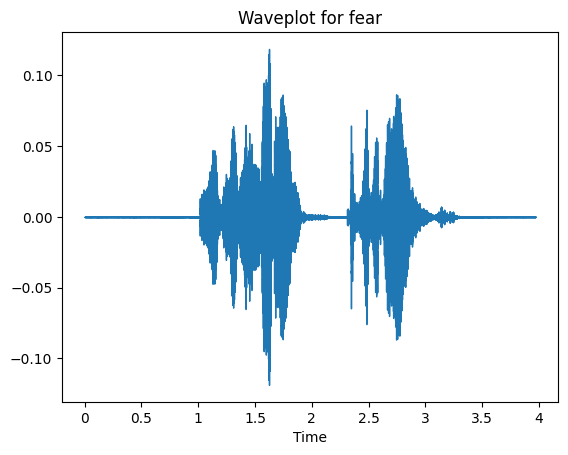

<ipython-input-11-6cb1dee788bf>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)


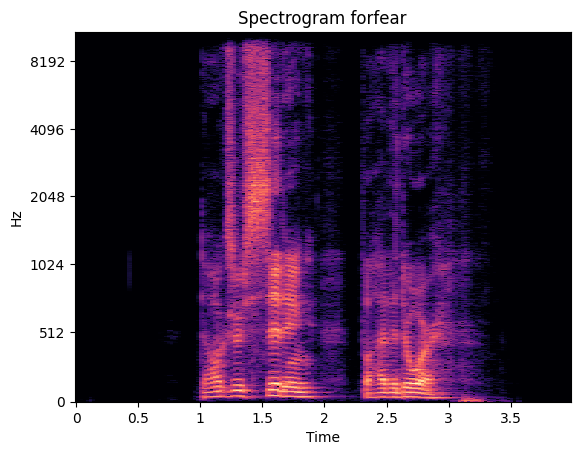

In [12]:
emotion = 'fear'
path = np.array(data_path.Path[data_path['Emotions']==emotion])[2]
path=path.replace('versions/1Actor','versions/1/Actor')
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

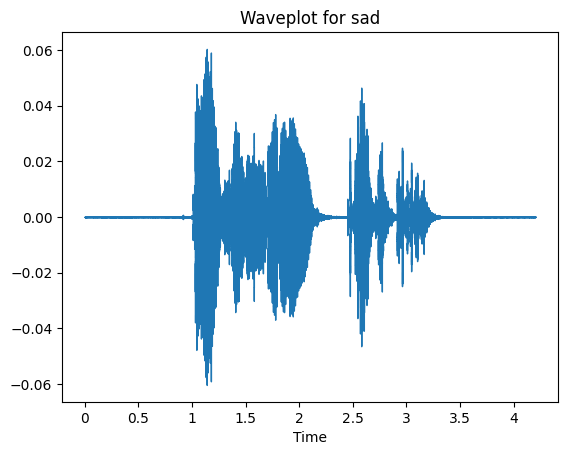

<ipython-input-11-6cb1dee788bf>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)


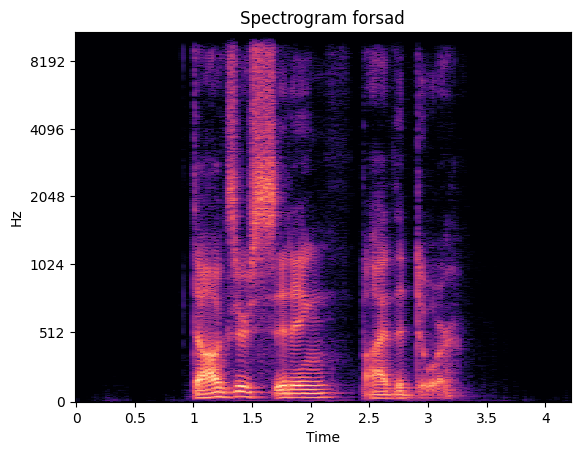

In [13]:
emotion = 'sad'
path = np.array(data_path.Path[data_path['Emotions']==emotion])[1]
path=path.replace('versions/1Actor','versions/1/Actor')
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

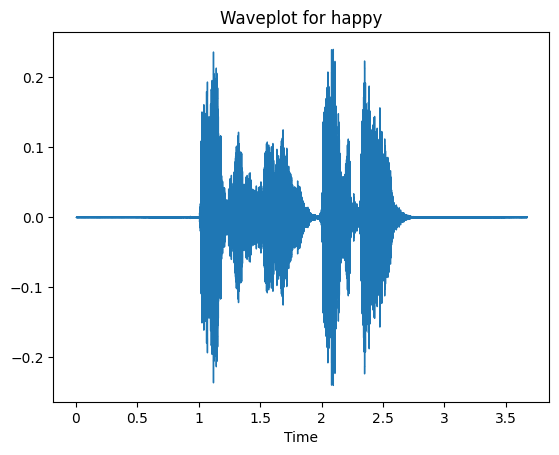

<ipython-input-11-6cb1dee788bf>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)


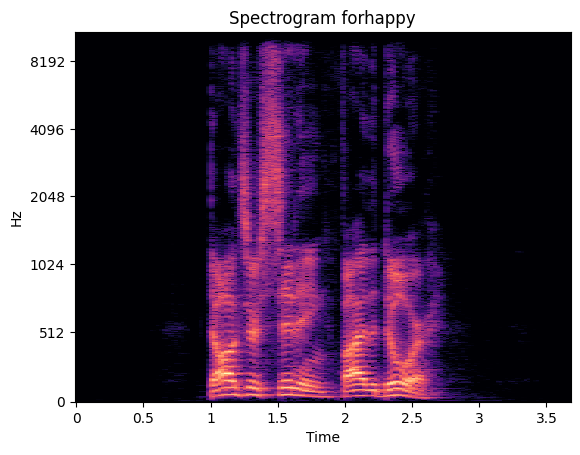

In [14]:
emotion = 'happy'
path = np.array(data_path.Path[data_path['Emotions']==emotion])[1]
path=path.replace('versions/1Actor','versions/1/Actor')
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

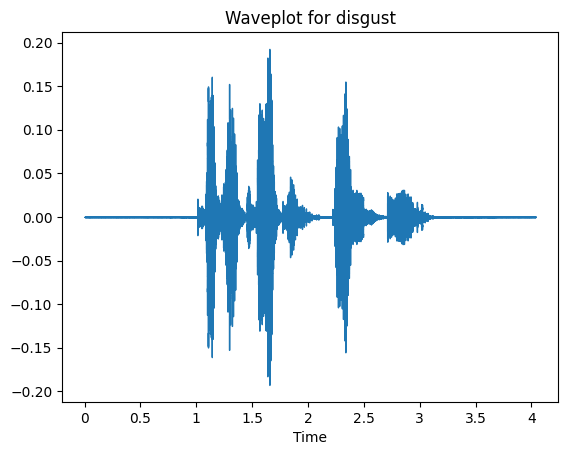

<ipython-input-11-6cb1dee788bf>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)


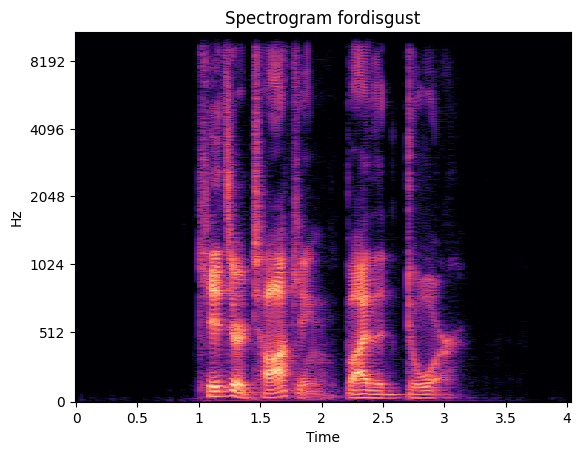

In [15]:
emotion = 'disgust'
path = np.array(data_path.Path[data_path['Emotions']==emotion])[1]
path=path.replace('versions/1Actor','versions/1/Actor')
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

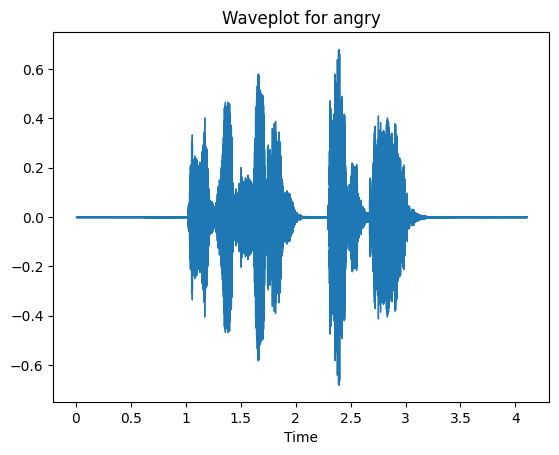

<ipython-input-11-6cb1dee788bf>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)


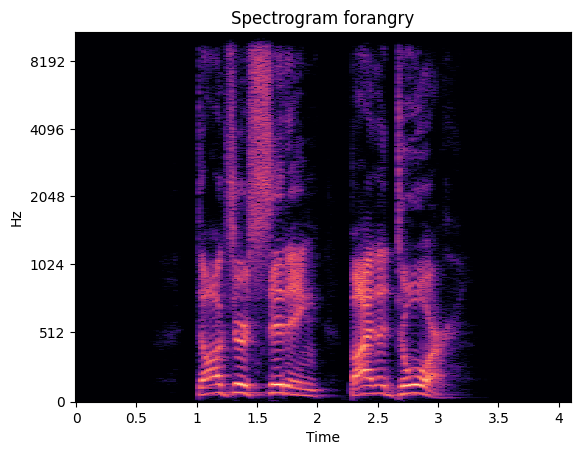

In [16]:
emotion = 'angry'
path = np.array(data_path.Path[data_path['Emotions']==emotion])[0]
path=path.replace('versions/1Actor','versions/1/Actor')
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

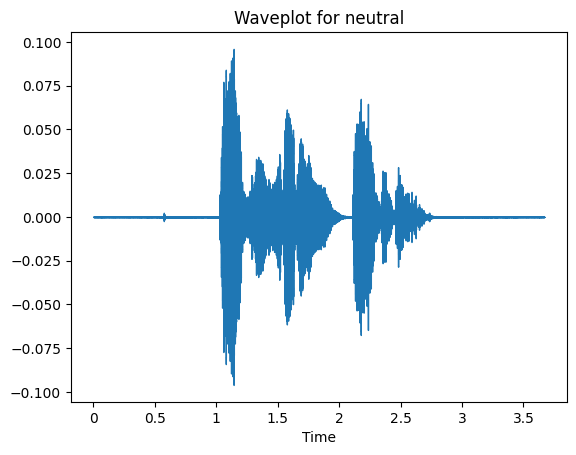

<ipython-input-11-6cb1dee788bf>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  mel_spect=librosa.amplitude_to_db(mel_spect,ref=np.max)


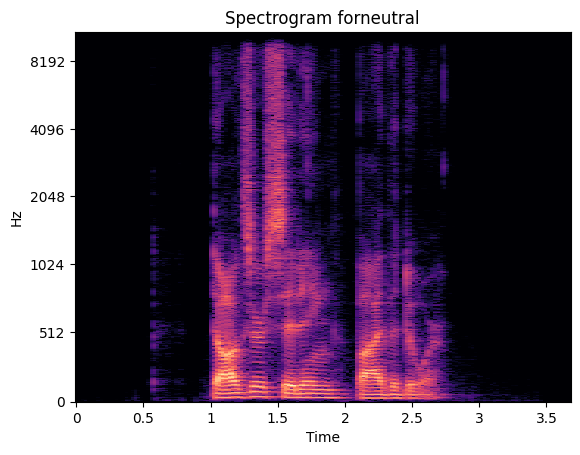

In [17]:
emotion = 'neutral'
path = np.array(data_path.Path[data_path['Emotions']==emotion])[1]
path=path.replace('versions/1Actor','versions/1/Actor')
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

In [18]:
def extract_mfcc(filename):
    filename=str(filename)

    if os.path.isfile(filename):
     y, sr = librosa.load(filename, duration=3, offset=0.5)
     mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
     return mfcc
    else:
      return None



In [19]:
extract_mfcc(data_path['Path'][0].iloc[0])

array([-4.4461908e+02,  8.4276985e+01, -1.9843765e+01,  1.5883853e+01,
        1.6037123e+01, -1.3109593e+01, -2.2193991e+01, -7.4111891e+00,
       -3.1916550e+01, -7.8615351e+00,  2.5135541e+00, -2.0645359e+01,
       -5.7368941e+00, -2.8059974e+00, -1.0431404e+01, -1.9830444e+00,
       -8.5486927e+00, -3.6448941e+00, -4.4709954e-01, -7.1435647e+00,
       -1.3425426e+00, -5.9624896e+00, -4.0021257e+00, -3.1386466e+00,
       -6.4151707e+00, -2.3048835e+00, -5.1104541e+00, -1.1337537e+00,
       -4.2063384e+00,  7.4990046e-01,  1.6384320e-01, -4.7901554e+00,
       -2.1696782e+00,  6.8962884e-01, -2.3807805e+00,  3.1550212e+00,
        2.5479174e+00,  3.5157983e+00,  8.1557536e-01,  3.5893056e+00],
      dtype=float32)

In [20]:
X_mfcc = data_path['Path'].apply(lambda x: extract_mfcc(x)).dropna()

In [21]:
X_mfcc

,Path
0,"[-444.61908, 84.276985, -19.843765, 15.883853,..."
1,"[-541.4544, 97.864, -3.2071304, 22.896542, 15...."
2,"[-557.4595, 87.569954, 0.64032173, 23.490332, ..."
3,"[-529.04895, 62.957077, -1.4373395, 9.3146, 6...."
4,"[-497.50046, 73.95188, -4.592461, 18.557158, 1..."
...,...
1459,"[-658.2824, 56.52901, -1.3194304, 6.4331713, 6..."
1460,"[-591.577, 66.02304, -10.278738, 0.99193585, 4..."
1461,"[-555.59424, 57.832054, -17.399124, 1.592499, ..."
1462,"[-609.7858, 51.978493, -5.0955524, -0.61504084..."


In [22]:
X= [x for x in X_mfcc if x is not None]
X=np.expand_dims(X,-1)
X.shape

(1440, 40, 1)

In [23]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(data_path[['Emotions']])
y=y.toarray()
y=np.resize(y,(1440,8))
y.shape

(1440, 8)

In [35]:
model=Sequential([Conv1D(216, kernel_size=5, activation='relu', input_shape=(40, 1)),

    MaxPooling1D(pool_size=3),
    Dropout(0.05),

    Conv1D(512, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=3),
    Dropout(0.05),

    Flatten(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(8, activation='softmax')  ])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
model.fit(X,y,epochs=45,validation_split=0.1)

Epoch 1/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.1477 - loss: 2.2782 - val_accuracy: 0.1389 - val_loss: 7.7002
Epoch 2/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.2351 - loss: 1.9948 - val_accuracy: 0.1389 - val_loss: 3.6433
Epoch 3/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.2897 - loss: 1.9013 - val_accuracy: 0.1389 - val_loss: 3.7116
Epoch 4/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.2914 - loss: 1.9363 - val_accuracy: 0.0833 - val_loss: 4.8135
Epoch 5/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.3126 - loss: 1.8702 - val_accuracy: 0.1111 - val_loss: 2.6651
Epoch 6/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3223 - loss: 1.8583 - val_accuracy: 0.1181 - val_loss: 2.4370
Epoch 7/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.3456 - loss: 1.7935 - val_accuracy: 0.1597 - val_loss: 2.5403
Epoch 8/45
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.3846 - loss: 1.7101 - val_accuracy: 0.1181 - v

In [38]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
y_pred_prob=model.predict(x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [40]:
y_pred_class=np.argmax(y_pred_prob,axis=1)
y_test_class=np.argmax(y_test,axis=1)

In [41]:
from sklearn.metrics import accuracy_score, r2_score
accuracy=accuracy_score(y_test_class,y_pred_class)
print(accuracy)

0.7708333333333334


In [42]:
report=classification_report(y_test_class,y_pred_class,output_dict=True)
print(report)

{'0': {'precision': 0.75, 'recall': 0.9, 'f1-score': 0.8181818181818182, 'support': 40.0}, '1': {'precision': 0.9393939393939394, 'recall': 0.7380952380952381, 'f1-score': 0.8266666666666667, 'support': 42.0}, '2': {'precision': 0.5714285714285714, 'recall': 0.9142857142857143, 'f1-score': 0.7032967032967034, 'support': 35.0}, '3': {'precision': 1.0, 'recall': 0.6666666666666666, 'f1-score': 0.8, 'support': 45.0}, '4': {'precision': 0.9375, 'recall': 0.7142857142857143, 'f1-score': 0.8108108108108109, 'support': 42.0}, '5': {'precision': 0.4444444444444444, 'recall': 0.8, 'f1-score': 0.5714285714285714, 'support': 20.0}, '6': {'precision': 0.9, 'recall': 0.8181818181818182, 'f1-score': 0.8571428571428571, 'support': 33.0}, '7': {'precision': 0.8695652173913043, 'recall': 0.6451612903225806, 'f1-score': 0.7407407407407407, 'support': 31.0}, 'accuracy': 0.7708333333333334, 'macro avg': {'precision': 0.8015415215822824, 'recall': 0.7745845552297166, 'f1-score': 0.766033521033521, 'support